graphing without ai. we start with one example of each barebones graph type.

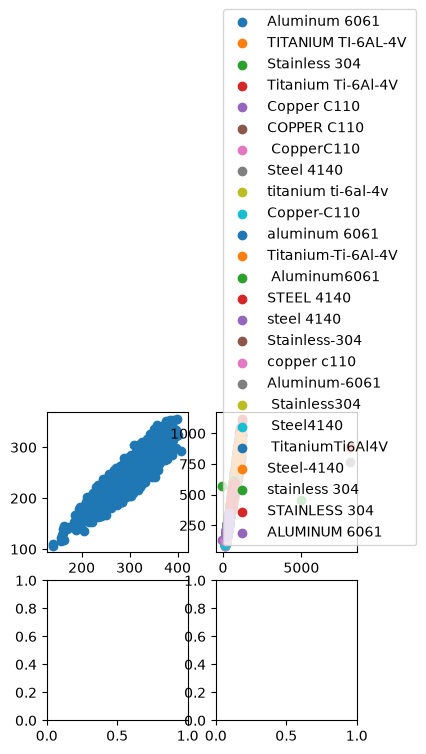

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('data/materials_qc_raw.csv')

fig, ax = plt.subplots(2, 2, figsize=(4, 4))

category = "Material "
x_column = "Tensile Strength (MPa)"
y_column = "Yield Strength (MPa)"

categorytolookat = df[df[category] == "Aluminum 6061"]
ax[0, 0].scatter(
    categorytolookat[x_column],
    categorytolookat[y_column],
)

for cat in df[category].unique():
    catlookat = df[df[category] == cat]
    ax[0, 1].scatter(
        catlookat[x_column],
        catlookat[y_column],
        label=cat,
    )

ax[0, 1].legend()
plt.show()

IndexError: index 2 is out of bounds for axis 0 with size 2

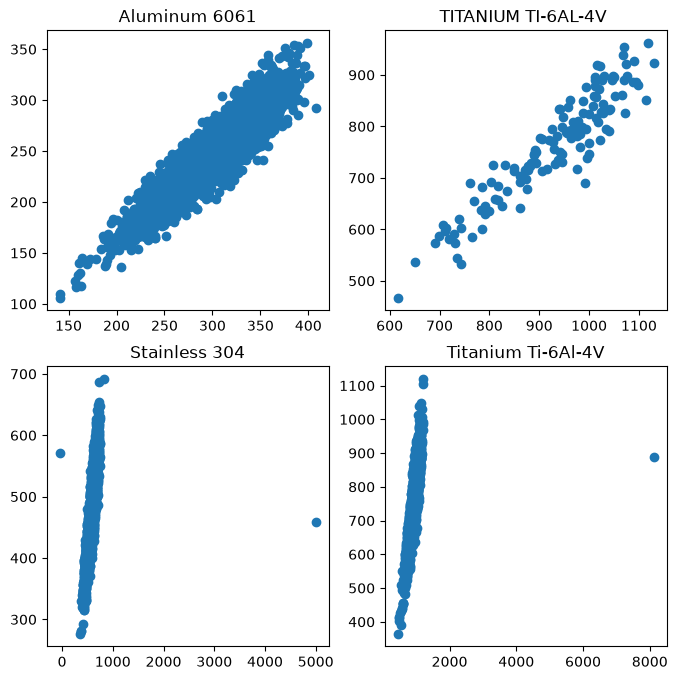

In [ ]:
# now trying to make a class that can do this for me
class Plotter:
    def __init__(self, data:pd.DataFrame):
        self.data = data
        self.x_measurement = None
        self.y_measurement = None
        self.category = None
        self.cat_selection = None
    def _plot(self, ax, x_measurement:str, y_measurement:str, category:str=None, cat_selection:str=None):
        self.x_measurement = self.data[x_measurement]
        self.y_measurement = self.data[y_measurement]
        self.category = category
        self.cat_selection = cat_selection
        if category and cat_selection: # if category and cat_selection are provided, filter the data accordingly
            data_to_plot = self.data[self.data[category] == cat_selection]
            ax.scatter(
                data_to_plot[x_measurement],
                data_to_plot[y_measurement],
            )
        elif category: # if only category is provided, plot all categories with different colors
            for cat in self.data[category].unique():
                catlookat = self.data[self.data[category] == cat]
                ax.scatter(
                    catlookat[x_measurement],
                    catlookat[y_measurement],
                    label=cat,
                )
            ax.legend()
        else:
            ax.scatter(
                self.x_measurement,
                self.y_measurement,
            )
    def simple_plot(self, x_measurement:str, y_measurement:str, category:str=None, cat_selection:str=None):
        fig, ax = plt.subplots(figsize=(4, 4))
        self._plot(ax, x_measurement, y_measurement, category, cat_selection)
        plt.xlabel(x_measurement)
        plt.ylabel(y_measurement)
        plt.show()
material_plotter = Plotter(df)
material_plotter.simple_plot("Tensile Strength (MPa)", "Yield Strength (MPa)", category="Material ")